[![Fixel Algorithms](https://fixelalgorithms.co/images/CCExt.png)](https://fixelalgorithms.gitlab.io)

# AI Program

## Smooth Optimization - Localization by DF (Direction Finding) 

> Notebook by:
> - Royi Avital RoyiAvital@fixelalgorithms.com

## Revision History

| Version | Date       | User        |Content / Changes                                                   |
|---------|------------|-------------|--------------------------------------------------------------------|
| 1.0.001 | 21/12/2025 | Royi Avital | Removed `anp.sum()` in the objective loop                          |
| 1.0.000 | 09/08/2025 | Royi Avital | First version                                                      |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FixelAlgorithmsTeam/FixelCourses/blob/master/AIProgram/2024_02/0002PointLine.ipynb)

In [1]:
# Import Packages

# General Tools
import numpy as np
import scipy as sp
import pandas as pd

# Scientific Python
import autograd.numpy as anp
import autograd.scipy as asp
from autograd import grad

# Miscellaneous
from platform import python_version
import random

# Typing 
from typing import Callable

# Visualization
import matplotlib.pyplot as plt

# Jupyter
from IPython import get_ipython

## Notations

* <font color='red'>(**?**)</font> Question to answer interactively.
* <font color='blue'>(**!**)</font> Simple task to add code for the notebook.
* <font color='green'>(**@**)</font> Optional / Extra self practice.
* <font color='brown'>(**#**)</font> Note / Useful resource / Food for thought.

Code Notations:

```python
someVar    = 2; #<! Notation for a variable
vVector    = np.random.rand(4) #<! Notation for 1D array
mMatrix    = np.random.rand(4, 3) #<! Notation for 2D array
tTensor    = np.random.rand(4, 3, 2, 3) #<! Notation for nD array (Tensor)
tuTuple    = (1, 2, 3) #<! Notation for a tuple
lList      = [1, 2, 3] #<! Notation for a list
dDict      = {1: 3, 2: 2, 3: 1} #<! Notation for a dictionary
oObj       = MyClass() #<! Notation for an object
dfData     = pd.DataFrame() #<! Notation for a data frame
dsData     = pd.Series() #<! Notation for a series
hObj       = plt.Axes() #<! Notation for an object / handler / function handler
```

### Code Exercise

 - Single line fill

```python
valToFill = ???
```

 - Multi Line to Fill (At least one)

 ```python
 # You need to start writing
 ?????
 ```

 - Section to Fill

```python
#===========================Fill This===========================#
# 1. Explanation about what to do.
# !! Remarks to follow / take under consideration.
mX = ???

?????
#===============================================================#
```

In [2]:
# Configuration
# %matplotlib inline

# warnings.filterwarnings("ignore")

seedNum = 512
np.random.seed(seedNum)
random.seed(seedNum)

# Matplotlib default color palette
lMatPltLibclr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
# sns.set_theme() #>! Apply SeaBorn theme
# sns.set_palette("tab10")

runInGoogleColab = 'google.colab' in str(get_ipython())

In [3]:
# Constants

FIG_SIZE_DEF    = (8, 8)
ELM_SIZE_DEF    = 50
CLASS_COLOR     = ('b', 'r')
EDGE_COLOR      = 'k'
MARKER_SIZE_DEF = 10
LINE_WIDTH_DEF  = 2

In [4]:
# Course Packages


In [5]:
# Auxiliary Functions


## Direction Finding Localization

DF ([Direction Finding](https://en.wikipedia.org/wiki/Direction_finding)) is a simple method to localize the location of an RF transmitter.

In classical DF for localization of RF Signal, each measurement yield a direction.  
When the direction is plotted on the map it creates a single line where the transmitter is believed to be on.  
With perfect measurements the intersection of 2 lines will reveal the location of the transmitter.  

Yet in practice, due to different inaccuracies in the model and measurements the real location is not at the intersection.  
One way to overcome some of those "noises" is use more than 2 measurements for the estimation.

![](https://i.imgur.com/HDt0YoF.png) Image Credit: [School Amateur Radio Club Network - Amateur Radio Direction Finding](https://www.sarcnet.org/amateur-radio-direction-finding.html)
<!-- ![](https://i.postimg.cc/8PsJwWYj/image.png) -->

* <font color='brown'>(**#**)</font> Using intersection of lines for localization is called [Triangulation](https://en.wikipedia.org/wiki/Triangulation).
* <font color='brown'>(**#**)</font> Farther reading on DF:
   - [Paul Denisowski - An Introduction to Radio Direction Finding Methodologies](http://www.denisowski.org/Publications/Denisowski%20-%20An%20Introduction%20to%20Radio%20Direction%20Finding%20Methodologies.pdf).
   - [Rohde Schwarz - An Introduction to Direction Finding Methodologies (White Paper)](https://cdn.rohde-schwarz.com/am/us/campaigns_2/a_d/Intro-to-direction-finding-methodologies~1.pdf).

### The Sum of Distances Minimization  

One approach to solve it is to find the point which minimizes the sum of distances to the lines:


$$ \arg \min_{\boldsymbol{x} \in \mathbb{R}^{2}} \sum_{i = 1}^{n} d \left( \boldsymbol{x}, \boldsymbol{l}_{i} \right) $$

Where $\boldsymbol{l}_{i}$ is the set of parameters of the $i$ -th line.  

This notebooks solve the problem for the case the distance is defined as the **Squared Euclidean** Distance.  
Given a set of lines, it derives and finds the point which minimizes the sum of squared distances.

* <font color='brown'>(**#**)</font> The accuracy of the model is mostly determined by the distance / dissimilarity function in use.  
In most cases the Squared Euclidean Distance is not a good measure to find the actual location.  
* <font color='brown'>(**#**)</font> The Squared Euclidean Distance does not form a valid metric as it does not hold the _Triangle Inequality_.  
  For instance: $ {\left| -2 - 2 \right|}^{2} \nleq {\left| -2 - 0 \right|}^{2} + {\left| 0 - 2 \right|}^{2}$.
* <font color='red'>(**?**)</font> Will the solution of the Squared Euclidean Distance be the same as the Euclidean Distance?

In [6]:
# Parameters

tuGrid = (-2, 2, 1000) #<! Left boundary, right boundary, num points

# Solver
μ       = 1e-4
numIter = 10_000

## Generate Data


### Create 1D Grid

In [7]:
# Generate 1D Grid

vX = np.linspace(tuGrid[0], tuGrid[1], tuGrid[2]) #<! Linear steps grid

print(f'The Grid Shape: {vX.shape}')

The Grid Shape: (1000,)


### Create Lines

Generate the `numLines` lines in 2 forms:

1. $a x + b y + c = 0$.
2. $y = m x + n$.

* <font color='brown'>(**#**)</font> The forms are equivalent (Assuming $b 
eq 0$). Namely the lines are the same, just in 2 different forms.

In [8]:
# Generate the Lines
# Lines parameters: a x + b y + c = 0

mL = np.array([[1, 1, 0], [-0.8, 1.7, -0.7], [-0.8, 1.6, -0.75], [1.1, -0.95, -0.05]]) #<! Lines parameters: a, b, c
numLines = mL.shape[0]

#===========================Fill This===========================#
# 1. Normalize the lines so that a^2 + b^2 = 1.
# !! Make sure the line is the same.

vN = np.linalg.norm(mL[:, 0:2], axis=1) #<! Calculate the norm of (a, b)
mL = mL / vN.reshape(4, 1) #<! Scales all parameters

#===============================================================#

In [9]:
# Convert the Lines into the y = m x + n Form

# The motivation is for visualization
mM = np.column_stack((-mL[:, 0] / mL[:, 1], -mL[:, 2] / mL[:, 1])) #<! Not safe, in production verify `mL[:, 1] != 0`

In [10]:
mM

array([[-1.        , -0.        ],
       [ 0.47058824,  0.41176471],
       [ 0.5       ,  0.46875   ],
       [ 1.15789474, -0.05263158]])

* <font color='red'>(**?**)</font> If all lines are valid functions, is the above operation safe? Consider in theory and in practice.

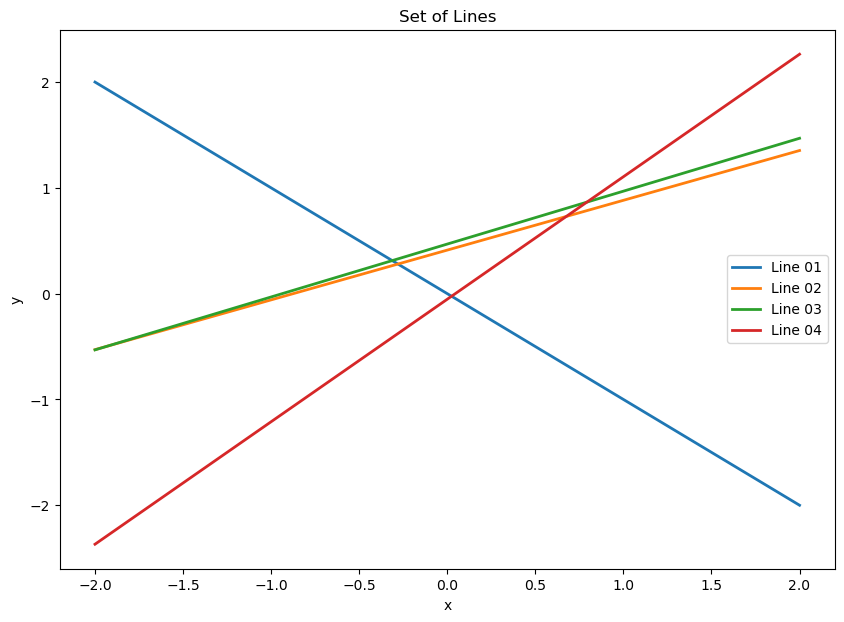

In [11]:
# Draw the Data

hF, hA = plt.subplots(figsize = (10, 7))

for ii in range(numLines):
    vY = np.array([mM[ii, 0] * valX + mM[ii, 1] for valX in vX])
    hA.plot(vX, vY, lw = LINE_WIDTH_DEF, label = f'Line {ii + 1:02d}')

hA.set_xlabel('x')
hA.set_ylabel('y')
hA.set_title('Set of Lines')

hA.legend();

## Deriving the Objective Function

This section formulates the problem as a _Quadratic Programming_ problem.

### Distance of a Point from a Line

Given a point $\boldsymbol{x} = \left[ {x}_{0}, {y}_{0} \right]^{T}$ then the _Euclidean Distance_ to a line, given by the parameters $l = \left( a, b, c \right) : a x + b y + c = 0$ is given by:

$$ d \left( \boldsymbol{x}, l \right) = \frac{ \left| a {x}_{0} + b {y}_{0} + c \right| }{ \sqrt{ {a}^{2} + {b}^{2} } } $$

Assuming all lines are normalized, then the operation becomes:

$$ d \left( \boldsymbol{x}, l \right) = a {x}_{0} + b {y}_{0} + c $$

The objective function, based on the _Squared Euclidean Distance_, for the DF as defined is given by:

$$ \arg \min_{\boldsymbol{x} \in \mathbb{R}^{2}} \sum_{i = 1}^{n} {d}^{2} \left( \boldsymbol{x}, \boldsymbol{l}_{i} \right) $$


* <font color='brown'>(**#**)</font> Using the Squared Euclidean as a measure of distance greatly simplifies the derivation of the solution.

### Simplified Form

Since a line is defined by $l = \left( a, b, c \right) : a x + b y + c = 0$, multiplying its parameters by a constant has no effect.  
Namely, lines are parameterized up to a scale. It means one can chose to have the line in a form which ${a}^{2} + {b}^{2} = 1$.

Given that, the optimization problem is given by:

$$ \arg \min_{\boldsymbol{x} \in \mathbb{R}^{2}} \sum_{i = 1}^{n} {d}^{2} \left( \boldsymbol{x}, \boldsymbol{l}_{i} \right) = \arg \min_{\boldsymbol{x} \in \mathbb{R}^{2}} \sum_{i = 1}^{n} {\left( {a}_{i} x + {b}_{i} y + {c}_{i} \right)}^{2} $$

* <font color='brown'>(**#**)</font> This form can be farther simplified so it can be solved as _Linear Least Squares_ problem.

In [12]:
# Define the Objective Function

def PointLineSumSqrDistance( vX: np.ndarray, mL: np.ndarray ) -> np.floating:
    """
    The function calculates the sum of squared distances of a point in 2D to a set of lines.
    For a line, `vL`, a row in the matrix `mL`:
    The line is given as `vL[0] * x + vL[1] * y + vL[2] = 0`.  
    The line is assumed to have `np.linalg.norm(vL[:2]) = 1`.
    Input:
        vX      - A point in 2D (2, ).
        mL      - Set of 2D lines parameters (numLines x 3).
    Output:
        sumDisSqr - The sum of squared distance to lines.
    """
    #===========================Fill This===========================#
    # 1. Set `sumDisSqr` to zero.
    # 2. Loop over lines and add the distance to the line.
    # !! Output must be a scalar.
    # !! You may use a vectorized method.
    
    sumDisSqr = 0
    for row in mL:
        sumDisSqr += (row[0] * vX[0] + row[1] * vX[1] + row[2]) **2  #<! Add the distance to the line
    #===============================================================#
    
    return sumDisSqr

In [13]:
for row in mL:
    print(row)

[0.70710678 0.70710678 0.        ]
[-0.42579704  0.9048187  -0.37257241]
[-0.4472136   0.89442719 -0.41926275]
[ 0.75682301 -0.65361987 -0.03440105]


In [14]:
# Find the Optimal Point

def FindOptimalPoint( vX: np.ndarray, hGradFun: Callable, /, *, μ: float = 1e-5, numIter: int = 10_000 ) -> np.ndarray:
    """
    The function finds the optimal point that minimizes the sum of squared distances to a set of lines.
    Input:
        vX       - The initial point in 2D (2, ).
        hGradFun - The gradient function of the objective function: `hGradFun(vX) -> vG`.
        μ        - The step size for the gradient descent.
        numIter  - The number of iterations for the gradient descent.
    Output:
        vX      - The optimal point in 2D (2, ).
    Remarks:
        - The function assumes the arrays `vX` and `mL` are AutoGrad arrays.
    """
    #===========================Fill This===========================#
    # 1. Create Gradient Descent loop.
    # 2. Calculate the gradient using `hGradFun`.
    # 3. Update the point using the Gradient Descent policy.
    # !! You may add a stopping condition.
    # !! You may add adaptive step size.

    for _ in range(numIter):
        vG = hGradFun(vX) #<! Calculate the gradient using `hGradFun()`
        vX = vX - vG * μ  #<! Update the point using gradient descent
    #===============================================================#
    
    return vX

* <font color='brown'>(**#**)</font> Production level implementation should add: Adaptive Step Size, Acceleration Method, Stopping Condition, Flag for Convergence.


In [15]:
# Find the Optimal Point Using Gradient Descent

hObjFun  = lambda vX: PointLineSumSqrDistance(vX, mL) #<! Define the objective function
hGradFun = grad(hObjFun) #<! Define the gradient function using `AutoGrad`
vP       = anp.zeros(2) #<! Initial point

vP = FindOptimalPoint(vP, hGradFun, μ = μ, numIter = numIter) #<! Find the point

* <font color='green'>(**@**)</font> Replace `FindOptimalPoint()` with `sp.optimize.fmin_bfgs()` and compare run time.

<!-- vP = anp.zeros(2)
vP = sp.optimize.fmin_bfgs(hObjFun, vP, hGradFun) -->

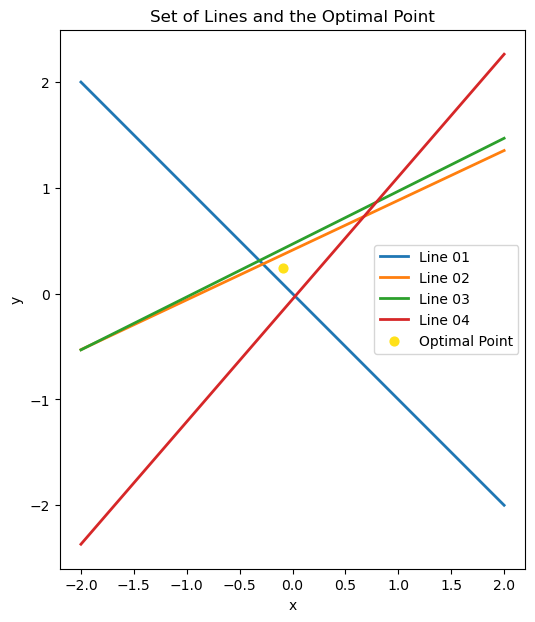

In [16]:
# Plot the Optimal Solution 

hF, hA = plt.subplots(figsize = (10, 7))

for ii in range(numLines):
    vY = np.array([mM[ii, 0] * valX + mM[ii, 1] for valX in vX])
    hA.plot(vX, vY, lw = LINE_WIDTH_DEF, label = f'Line {ii + 1:02d}')

hA.scatter(vP[0], vP[1], s = 4 * MARKER_SIZE_DEF, color = '#FFE119', label = 'Optimal Point', zorder = 2.1)

hA.set_aspect('equal') #<! Must in order to have 90 [Deg]
hA.set_xlabel('x')
hA.set_ylabel('y')
hA.set_title('Set of Lines and the Optimal Point')

hA.legend();

* <font color='green'>(**@**)</font> Create _Heatmap_ of the objective function.
* <font color='green'>(**@**)</font> Create _Heatmap_ of the _Euclidean Distance_ and compare.
* <font color='red'>(**?**)</font> In what cases the Squared Euclidean Distance will fail?